In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import librosa
from tqdm import tqdm
import soundfile as sf

# Carga y preparación del dataset

In [4]:
data_path = "audio_16k"

class_map = {
    "laughter": 0,
    "sigh": 1,
    "cough": 2,
    "throatclearing": 3,
    "sneeze": 4,
    "sniff": 5
}

X = []
y = []

DURACION_SEGUNDOS = 3

MAX_MUESTRAS = 16000 * DURACION_SEGUNDOS 

files = [f for f in os.listdir(data_path) if f.endswith(".wav")]

for file in tqdm(files, desc="Procesando audios homogéneos"):
    label_name = file.split("_")[-1].replace(".wav", "")
    
    if label_name in class_map:
        label = class_map[label_name]
        file_path = os.path.join(data_path, file)
        
        try:
           
            audio, sr = sf.read(file_path)
            
            
            if len(audio.shape) > 1:
                audio = np.mean(audio, axis=1)
            
           
            if len(audio) > MAX_MUESTRAS:
                
                audio = audio[:MAX_MUESTRAS]
            else:
                
                audio = np.pad(audio, (0, MAX_MUESTRAS - len(audio)), mode='constant')
            
            X.append(audio)
            y.append(label)
            
        except Exception as e:
            print(f"Error con el archivo {file}: {e}")


X = np.array(X)  
y = np.array(y)

print("Forma de X:", X.shape)  
print("Forma de y:", y.shape)  
print("Clases únicas encontradas:", np.unique(y, return_counts=True))

Procesando audios homogéneos: 100%|██████████| 21024/21024 [03:26<00:00, 101.75it/s]


Forma de X: (21024, 48000)
Forma de y: (21024,)
Clases únicas encontradas: (array([0, 1, 2, 3, 4, 5]), array([3504, 3504, 3504, 3504, 3504, 3504]))


# División de datos en entrenamiento y prueba

In [5]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# Creación del Dataset y DataLoader

In [6]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y, augment=False):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).long()
        self.augment = augment
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        x = self.X[ix].clone() 
        
        if self.augment:
            
            if np.random.rand() < 0.5:
                
                noise_factor = 0.005  
                noise = torch.randn_like(x) * noise_factor * torch.std(x)
                x = x + noise
                
            
            if np.random.rand() < 0.5:
                
                shift_max = 2000
                shift = np.random.randint(-shift_max, shift_max)
                x = torch.roll(x, shifts=shift)
               
                if shift > 0:
                    x[:shift] = 0
                else:
                    x[shift:] = 0
                    
        
            if np.random.rand() < 0.5:
                gain_factor = np.random.uniform(0.8, 1.2)
                x = x * gain_factor

        max_val = torch.max(torch.abs(x))
        if max_val > 0:
            x = x / max_val
            
        return x, self.Y[ix]

dataset = {
    'train': Dataset(X_train, y_train, augment=True),
    'test': Dataset(X_test, y_test, augment=False),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=64, shuffle=True),
    'test': torch.utils.data.DataLoader(dataset['test'], batch_size=128, shuffle=False)
}

len(dataset['train']), len(dataset['test'])

(16819, 4205)

 # Definición de funciones y modelo

In [7]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in,H,D_out,p=0.3):
    return torch.nn.Sequential(
    
        torch.nn.Linear(D_in, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p), 
         
       torch.nn.Linear(H, H//2),
       torch.nn.BatchNorm1d(H//2),
       torch.nn.ReLU(),
       torch.nn.Dropout(p), 
           
        torch.nn.Linear(H//2, D_out)
    )

def fit(model, dataloader, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()
    
    l, acc = [], []
    test_l, test_acc = [], []
    best_acc, step = 0, 0
    
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
    
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['test']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        test_l.append(np.mean(_l))
        test_acc.append(np.mean(_acc))
       
        if test_acc[-1] > best_acc:
            best_acc = test_acc[-1]
            torch.save(model.state_dict(), '1p.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
    
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} test_loss {test_l[-1]:.5f} test_acc {test_acc[-1]:.5f}")
   
    model.load_state_dict(torch.load('1p.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'test_loss': test_l, 'test_acc': test_acc}

# Entrenamiento del modelo

In [8]:
D_in=X_train.shape[1]
H=64
D_out=len(np.unique(y_train))

model = build_model(D_in, H, D_out, p=0.5)
hist_adam = fit(model, dataloader,epochs=100,
                log_each=10 ,weight_decay=0.001, early_stopping=15)
print(model)

Mejor modelo guardado con acc 0.27522 en epoch 1
Mejor modelo guardado con acc 0.27882 en epoch 2
Mejor modelo guardado con acc 0.28071 en epoch 6
Mejor modelo guardado con acc 0.28726 en epoch 8
Mejor modelo guardado con acc 0.28837 en epoch 10
Epoch 10/100 loss 1.62374 acc 0.32691 test_loss 1.66125 test_acc 0.28837
Mejor modelo guardado con acc 0.29141 en epoch 11
Mejor modelo guardado con acc 0.29417 en epoch 12
Mejor modelo guardado con acc 0.30581 en epoch 14
Epoch 20/100 loss 1.60885 acc 0.34297 test_loss 1.65584 test_acc 0.29455
Mejor modelo guardado con acc 0.30756 en epoch 24
Epoch 30/100 loss 1.59862 acc 0.35613 test_loss 1.65479 test_acc 0.28987
Entrenamiento detenido en epoch 39 por no mejorar en 15 epochs seguidas
Sequential(
  (0): Linear(in_features=48000, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=64, out_feature

# Gráficas de pérdida y precisión

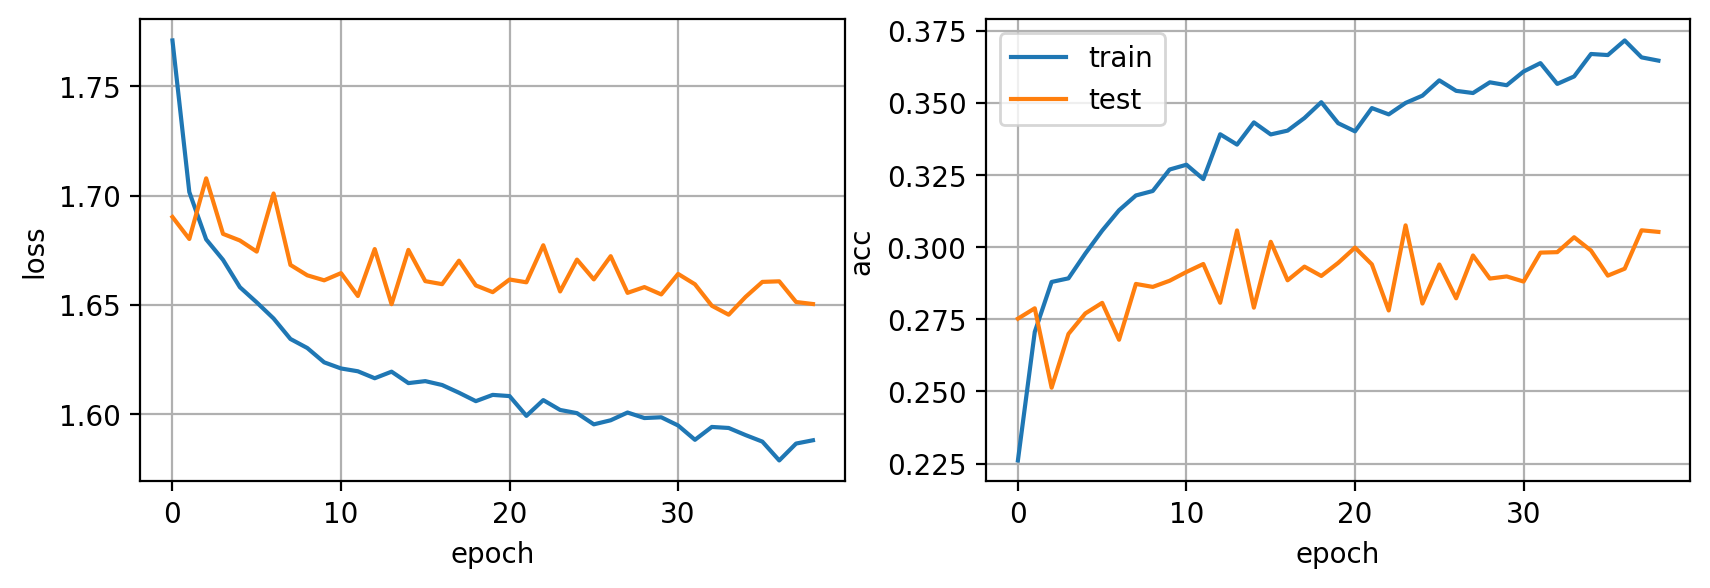

In [9]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_adam['loss'])
ax.plot(hist_adam['test_loss'])
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_adam['acc'],label='train')
ax.plot(hist_adam['test_acc'],label='test')
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
ax.legend() 
plt.show()



In [10]:
def evaluate(model, val_loader):
    model.eval()
    lista_predicciones = []
    with torch.no_grad():
        for x_b, _ in val_loader:
            x_b = x_b.float()
            outputs = model(x_b)
            _, preds = torch.max(outputs, dim=1)
        
            lista_predicciones.append(preds.cpu().numpy())

    predicciones_finales = np.concatenate(lista_predicciones)
    
    
    return predicciones_finales.astype(int)


In [11]:
y_pred = evaluate(model, dataloader['test'])

# Matriz de confusión

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.30725326991676577

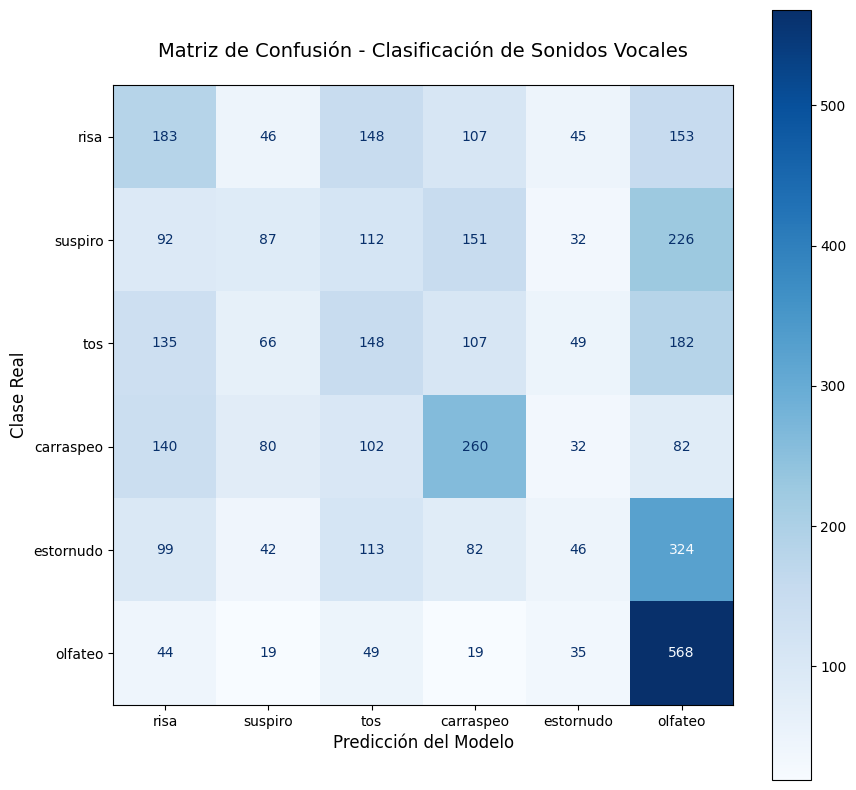

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
nombres_clases = ["risa", "suspiro", "tos", "carraspeo", "estornudo", "olfateo"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
fig, ax = plt.subplots(figsize=(10, 10)) 
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d') 

plt.title('Matriz de Confusión - Clasificación de Sonidos Vocales', fontsize=14, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

# Precision Recall

In [14]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
for i in range(6):
    print(f"Clase {i}: Precision: {precision[i] * 100:.2f}%, Recall: {recall[i] * 100:.2f}%")

Clase 0: Precision: 26.41%, Recall: 26.83%
Clase 1: Precision: 25.59%, Recall: 12.43%
Clase 2: Precision: 22.02%, Recall: 21.54%
Clase 3: Precision: 35.81%, Recall: 37.36%
Clase 4: Precision: 19.25%, Recall: 6.52%
Clase 5: Precision: 37.00%, Recall: 77.38%


In [15]:

micro= precision_score(y_test, y_pred, average='micro')
print(f"Precision  {micro * 100:.2f}%")


Precision  30.73%


In [16]:

micro= recall_score(y_test, y_pred, average='micro')
print(f"Recall  {micro * 100:.2f}%")

Recall  30.73%


# F1-Score

In [17]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average=None)
for i in range(6):
    print(f"Clase {i}: F1 Score: {f1[i] * 100:.2f}%")


Clase 0: F1 Score: 26.62%
Clase 1: F1 Score: 16.73%
Clase 2: F1 Score: 21.78%
Clase 3: F1 Score: 36.57%
Clase 4: F1 Score: 9.74%
Clase 5: F1 Score: 50.07%


In [18]:
micro= f1_score(y_test, y_pred, average='micro')
print(f"F1 Score : {micro * 100:.2f}%")

F1 Score : 30.73%


In [19]:
def evaluate2(model, val_loader):
    model.eval()
    
    lista_probabilidades = []
    
    with torch.no_grad():
        for x_b, _ in val_loader:
            x_b = x_b.float()
            outputs = model(x_b)
    
            probs = torch.softmax(outputs, dim=1)
        
            lista_probabilidades.append(probs.cpu().numpy())
            
    probabilidades_finales = np.concatenate(lista_probabilidades)
    
    return probabilidades_finales

In [20]:
y_pred=evaluate(model, dataloader['test'])
y_pred2 = evaluate2(model, dataloader['test'])

print(f"y_pred  {y_pred}")
print(f"y_pred shape {y_pred.shape}")
print(f"y_pred2 {y_pred2}")
print(f"y_pred2 shape {y_pred2.shape}")

y_pred  [0 5 5 ... 3 2 5]
y_pred shape (4205,)
y_pred2 [[0.21008982 0.16134849 0.194965   0.18703283 0.15864474 0.08791905]
 [0.0655843  0.11230733 0.07742879 0.03128923 0.23828188 0.47510844]
 [0.08938982 0.12331179 0.09859008 0.04281705 0.23900147 0.40688983]
 ...
 [0.18029743 0.20006733 0.15216538 0.3814055  0.07892809 0.00713624]
 [0.20583038 0.16055669 0.20754825 0.14297488 0.16241273 0.12067705]
 [0.18166354 0.13380744 0.1488447  0.0855824  0.21233182 0.23777016]]
y_pred2 shape (4205, 6)


# curva ROC

In [21]:
from sklearn.metrics import roc_curve
fpr_all=[]
tpr_all=[]
thresholds_all=[]
for i in range(6):
    fpr, tpr, thresholds = roc_curve(
        (y_test == i).astype(int),
        y_pred2[:, i]
    )
    fpr_all.append(fpr)
    tpr_all.append(tpr)
    thresholds_all.append(thresholds)

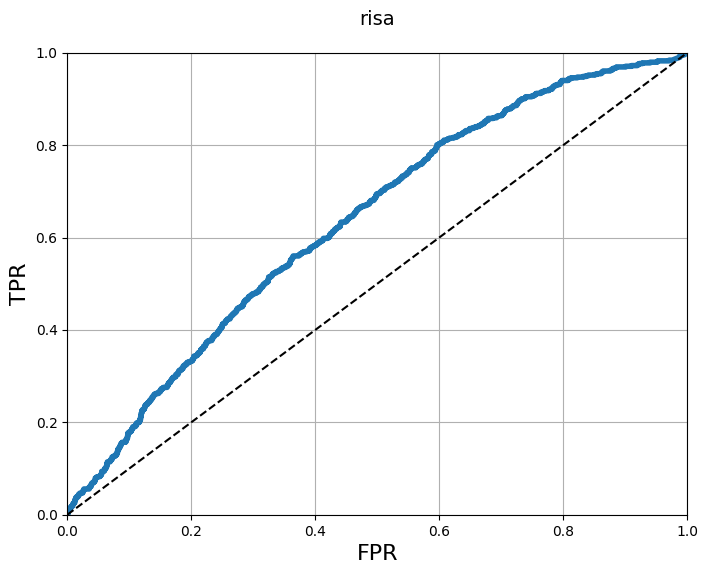

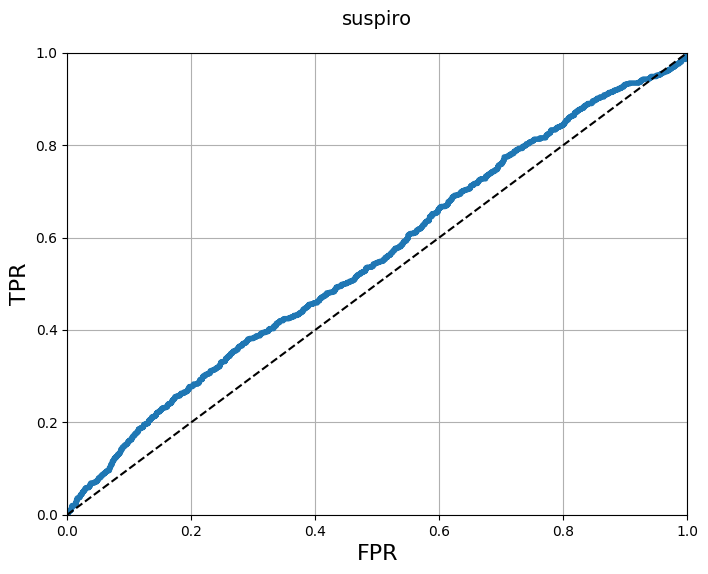

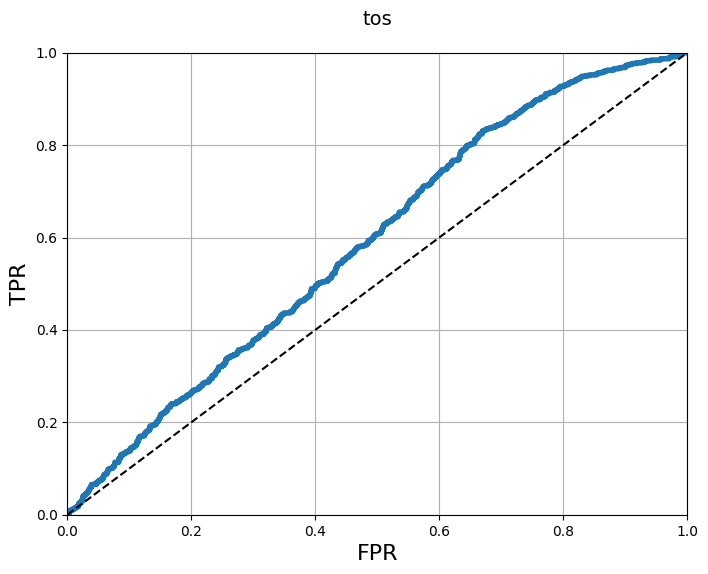

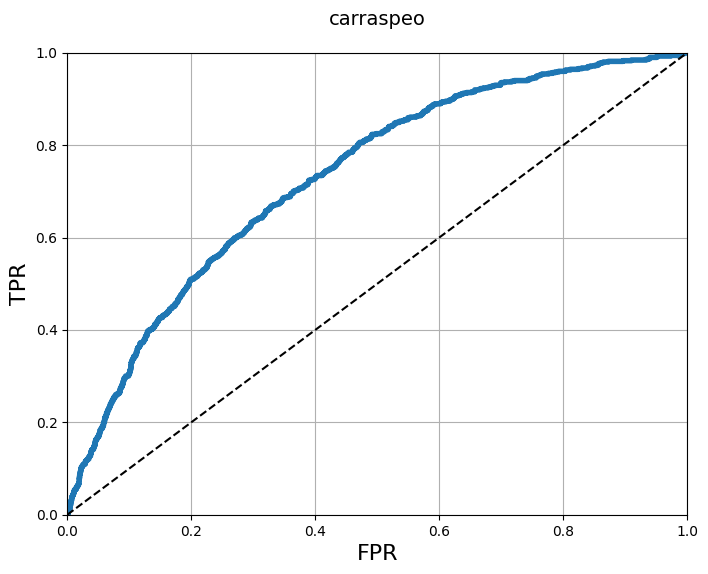

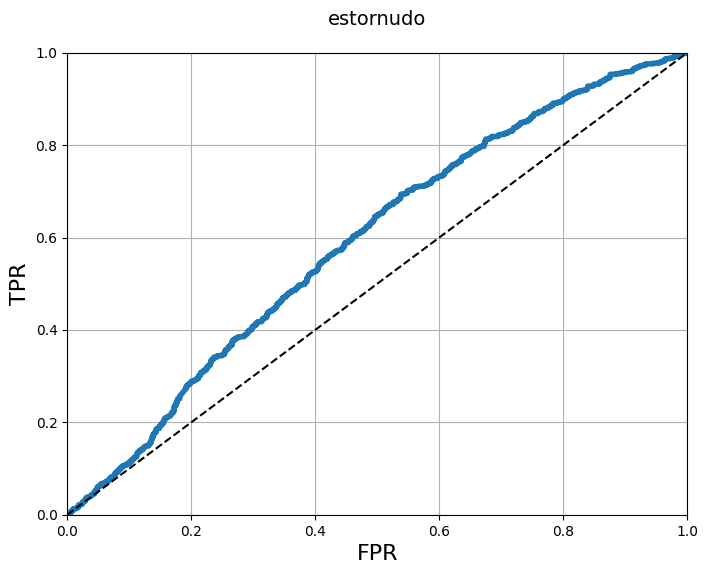

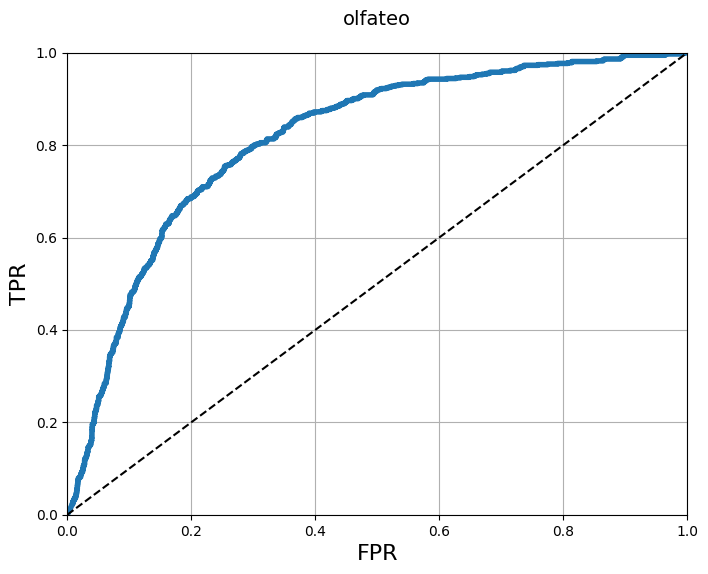

In [22]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.title(label, fontsize=14, pad=20)
    plt.plot(fpr, tpr, linewidth=4, label=label)
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.axis([0, 1, 0, 1])                                    
    plt.xlabel('FPR', fontsize=16) 
    plt.ylabel('TPR', fontsize=16)    
    plt.grid(True)                                            

                      
for i in range(6):
    plt.figure(figsize=(8, 6))   
    plot_roc_curve(fpr_all[i], tpr_all[i], label=nombres_clases[i])          
    plt.show()

# AUC-ROC

In [23]:
from sklearn.metrics import roc_auc_score
roc=roc_auc_score(y_test, y_pred2, multi_class='ovr', average=None)
for i in range(6):
    print(f"Clase {i}: ROC AUC Score: {roc[i] * 100:.2f}%")


Clase 0: ROC AUC Score: 63.46%
Clase 1: ROC AUC Score: 55.18%
Clase 2: ROC AUC Score: 58.79%
Clase 3: ROC AUC Score: 72.98%
Clase 4: ROC AUC Score: 59.00%
Clase 5: ROC AUC Score: 81.22%


In [ ]:
auc_score = roc_auc_score(y_test, y_pred2, multi_class='ovr', average='micro')
print(f"El AUC-ROC : {auc_score*100:.4f}")


El AUC-ROC : 66.9533
